# [TEMP] 1. Prefill and Decode

Every LLM request goes through two very different phases:

**Prefill**
: The model reads the whole prompt in one forward pass and writes the
  key/value (KV) vectors of every prompt token into the **KV cache**. It
  ends by emitting the first output token.

**Decode**
: The model generates the remaining tokens one at a time. Each step does a
  forward pass for a *single* new token per request, reusing the KV cache.

Users experience these two phases as two separate latencies:

| Metric | Definition | Dominated by |
|---|---|---|
| **TTFT** (time to first token) | arrival → first token | queueing + prefill |
| **TPOT** (time per output token) | average gap between later tokens | decode steps |
| **E2E latency** | arrival → last token | ≈ TTFT + TPOT × (output tokens − 1) |

In this lecture you will measure all three in simulation and work out *why*
prefill and decode scale so differently.

:::{admonition} Learning goals
- Run a simulation and read its latency metrics.
- Explain why prefill time grows with prompt length but decode time per token barely does.
- Classify prefill and decode as compute-bound or memory-bound, and estimate both
  from first principles.
:::

## Setup

Click **Open in Colab** or **Launch Binder** at the top right of this page to
run it in your browser. No GPU is needed: the course's simulator models an LLM
serving system on the CPU.

The simulations in these lectures rely on
[Vidur-Agent](https://github.com/psu-paws/Vidur-Agent), which extends Microsoft's
[Vidur](https://github.com/microsoft/vidur) LLM inference simulator
(Agrawal et al., MLSys 2024). We use them as the simulation engine.
`llm_systems_wo_gpus` (imported as `lsg`) is an easy-to-use wrapper we built on
top of them just for these lectures: it installs the simulator, turns its hundreds
of command-line flags into a few Python arguments, and returns results as tables.

:::{note}
To run for free on Colab (~12 GB of RAM, 2 CPU cores), `lsg` uses a
**stripped-down configuration** of the simulator. It precomputes kernel runtimes
only up to **16,384 tokens per request** (prompt + output), batches of **128
requests**, and prefill chunks of **4,096 tokens**, and `simulate` raises an error
beyond them. These are limits of this course setup, not of the simulator:
the full Vidur-Agent handles far longer contexts and was validated against much
longer, real multi-turn agent traces. With more memory you can raise them in
`LITE_GRID` inside `llm_systems_wo_gpus.py`.
:::

The first run downloads the simulator and installs its dependencies, which takes
about a minute.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

Simulator ready at /home/kiwan/.llm-systems-wo-gpus/backend


## The system we simulate

We serve **Qwen2.5-32B-Instruct** on **two NVIDIA A100-80GB GPUs**. Its 32.8B
parameters take 65.5 GB in 16-bit precision, which would leave almost no room for
the KV cache on one 80 GB GPU. So the model is split across two GPUs with
*tensor parallelism* (lecture 4), and each GPU holds half of every weight matrix.

| | Qwen2.5-32B-Instruct |
|---|---|
| Layers | 64 |
| Hidden size | 5,120 |
| Attention heads (query / KV) | 40 / 8 |
| MLP hidden size | 27,648 |
| Parameters | 32.8 B (65.5 GB in bf16) |

Every simulation in this lecture uses this setup, so we store it once:

In [2]:
SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

## Running a simulation

`lsg.simulate(...)` describes a system and a workload, runs the simulator, and
returns the result. Here 10 requests (512 prompt tokens, 128 output tokens each)
arrive at `qps=0.05` requests per second, i.e. one every 20 s on average. Since
each takes ~5 s, they rarely overlap: almost every request has the GPUs to itself.

The first call for a new (model, GPU, parallelism) combination takes ~15 s
while the simulator fits its runtime predictors. Later calls take a few seconds.

In [3]:
r = lsg.simulate(**SYSTEM, qps=0.05, num_requests=10, prefill_tokens=512, decode_tokens=128)
r.summary()

requests               10.000
TTFT p50 (ms)          99.608
TTFT p99 (ms)         174.187
TPOT p50 (ms)          39.388
TPOT p99 (ms)          39.699
E2E p50 (s)             5.141
queueing p50 (ms)       0.000
throughput (tok/s)     26.055
makespan (s)          245.636
dtype: float64

`r.summary()` aggregates over requests (p50 = median, p99 = 99th percentile).
`r.requests` has one row per request with every metric the simulator records:

In [4]:
r.requests[["request_num_prefill_tokens", "request_num_decode_tokens",
            "prefill_e2e_time", "decode_time_execution_plus_preemption_normalized",
            "request_e2e_time"]].head()

,request_num_prefill_tokens,request_num_decode_tokens,prefill_e2e_time,decode_time_execution_plus_preemption_normalized,request_e2e_time
0,512,128,0.099608,0.039388,5.141283
1,512,128,0.099608,0.039388,5.141283
2,512,128,0.099608,0.039388,5.141283
3,512,128,0.099608,0.039633,5.172584
4,512,128,0.175025,0.039090,5.178607


Check the E2E formula from the table above: TTFT + TPOT × 127 should come
close to the measured E2E latency.

In [5]:
s = r.summary()
print(f"TTFT + 127*TPOT = {s['TTFT p50 (ms)'] + 127 * s['TPOT p50 (ms)']:.0f} ms;"
      f"  measured E2E = {1e3 * s['E2E p50 (s)']:.0f} ms")

TTFT + 127*TPOT = 5102 ms;  measured E2E = 5141 ms


## Prefill scales with the prompt

To vary one parameter, use `lsg.sweep(name, values, **other_args)`. It calls
`simulate` once per value and returns a table with one summary row per value,
ready to plot. Here we vary the prompt length and keep the output at 32 tokens.

In [6]:
prompt = lsg.sweep("prefill_tokens", [128, 256, 512, 1024, 2048, 4096, 8192, 16000],
                   **SYSTEM, decode_tokens=32, qps=0.05, num_requests=10)
prompt[["TTFT p50 (ms)", "TPOT p50 (ms)"]]

,TTFT p50 (ms),TPOT p50 (ms)
prefill_tokens,,
128.0,41.279,38.693
256.0,60.279,38.468
512.0,99.608,38.470
1024.0,199.641,38.407
2048.0,402.149,38.432
4096.0,821.554,38.454
8192.0,1718.423,38.485
16000.0,3644.432,38.975


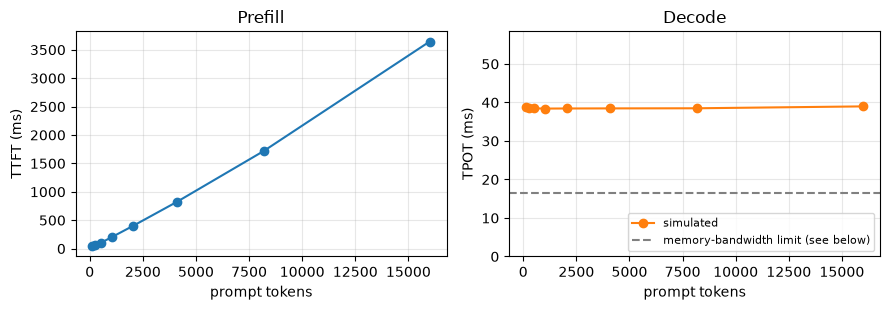

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(prompt.index, prompt["TTFT p50 (ms)"], "o-")
ax[0].set(xlabel="prompt tokens", ylabel="TTFT (ms)", title="Prefill")
ax[1].plot(prompt.index, prompt["TPOT p50 (ms)"], "o-", color="C1", label="simulated")
ax[1].axhline(32.8e9 * 2 / 2 / 2.0e12 * 1e3, ls="--", color="gray",
              label="memory-bandwidth limit (see below)")
ax[1].set(xlabel="prompt tokens", ylabel="TPOT (ms)", title="Decode",
          ylim=(0, 1.5 * prompt["TPOT p50 (ms)"].max()))
ax[1].legend(loc="lower right", fontsize=8)
fig.tight_layout()

TTFT grows **linearly** with the prompt: about 0.2 ms per prompt token. TPOT
does not move at all, even at 16K tokens, although every decode step reads the
whole prompt's KV cache.

## Prefill is compute-bound

A forward pass over $N$ tokens costs about $2 \times (\text{parameters}) \times N$
floating-point operations: one multiply and one add per weight per token. Each
weight is loaded from memory once and reused for all $N$ tokens, so for long
prompts the arithmetic, not the memory traffic, sets the time:

$$
\text{TTFT} \gtrsim \frac{2 \times 32.8\times 10^9 \times N}{2\ \text{GPUs} \times 312\ \text{TFLOP/s}}
$$

In [8]:
params, a100_flops, n_gpus = 32.8e9, 312e12, 2
for n in (1024, 4096, 16000):
    bound = 2 * params * n / (n_gpus * a100_flops)
    sim = prompt.loc[n, "TTFT p50 (ms)"] / 1e3
    print(f"N={n:>5}: compute bound {1e3 * bound:6.0f} ms, simulated {1e3 * sim:6.0f} ms "
          f"-> GPUs run at {bound / sim:.0%} of peak FLOP/s")

N= 1024: compute bound    108 ms, simulated    200 ms -> GPUs run at 54% of peak FLOP/s
N= 4096: compute bound    431 ms, simulated    822 ms -> GPUs run at 52% of peak FLOP/s
N=16000: compute bound   1682 ms, simulated   3644 ms -> GPUs run at 46% of peak FLOP/s


Prefill keeps the GPUs' math units about half busy, which is typical for real
kernels. Doubling the prompt doubles the work, and so doubles TTFT. (Attention
adds a term that grows with $N^2$, but at these lengths the weight matrices dominate.)

## Decode is memory-bound

A decode step processes **one** token per request. Every weight is still loaded
from GPU memory (HBM), but now it is used for only one multiply-add. The step
does $2 \times 32.8\times10^9$ FLOPs, about 0.1 ms of math on two A100s. But each GPU
must also stream its half of the 65.5 GB of weights through the memory system:

$$
\text{TPOT} \gtrsim \frac{65.5\ \text{GB} \,/\, 2\ \text{GPUs}}{2.0\ \text{TB/s per GPU}} \approx 16\ \text{ms}.
$$

In [9]:
weights_bytes, a100_bw = params * 2, 2.0e12
bound = weights_bytes / n_gpus / a100_bw
print(f"memory bound {1e3 * bound:.1f} ms, compute bound "
      f"{1e3 * 2 * params / (n_gpus * a100_flops):.2f} ms, simulated TPOT {s['TPOT p50 (ms)']:.1f} ms")

memory bound 16.4 ms, compute bound 0.11 ms, simulated TPOT 39.4 ms


Memory traffic, not arithmetic, sets the decode time: the memory bound is
~150× the compute bound. The simulated TPOT is ~2.4× even the memory bound,
because at batch size one many kernels are too small to reach peak bandwidth,
and every layer adds fixed costs (kernel launches, normalization layers, and the
communication between the two GPUs). The simulator's runtimes come from
**profiling real A100s**, so they include all of these.

This is also why TPOT ignores the prompt length: the KV cache of a 16K-token
prompt is $2 \times 64\ \text{layers} \times 8\ \text{KV heads} \times 128 \times 2\ \text{B} \times 16\text{K} \approx 4\ \text{GB}$,
small next to the 65.5 GB of weights read every step.

## Decode scales with the output

With the prompt fixed, E2E latency is a straight line in the number of output
tokens, and its slope is the TPOT.

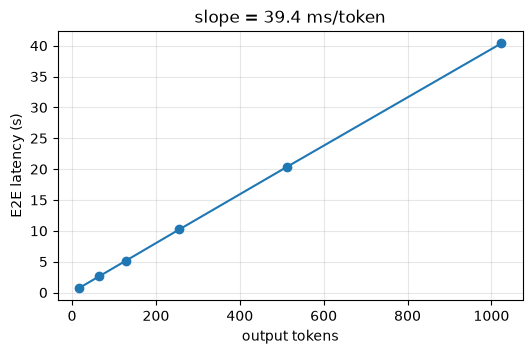

In [10]:
out = lsg.sweep("decode_tokens", [16, 64, 128, 256, 512, 1024],
                **SYSTEM, prefill_tokens=512, qps=0.05, num_requests=10)
plt.plot(out.index, out["E2E p50 (s)"], "o-")
plt.xlabel("output tokens"); plt.ylabel("E2E latency (s)")
slope = (out["E2E p50 (s)"].iloc[-1] - out["E2E p50 (s)"].iloc[0]) / (out.index[-1] - out.index[0])
plt.title(f"slope = {1e3 * slope:.1f} ms/token");

## Where does the time go?

Which phase matters more for a whole request? We simulate a grid of request
shapes, from short prompts to 15K-token documents and from 64 to 1,024 output
tokens, and split each request's E2E latency into **prefill** (the TTFT) and
**decode** (everything after the first token).

In [11]:
import pandas as pd

rows = []
for p_len in (256, 1024, 4096, 15000):
    for d_len in (64, 256, 1024):
        s_ = lsg.simulate(**SYSTEM, prefill_tokens=p_len, decode_tokens=d_len,
                          qps=0.05, num_requests=5).summary()
        ttft = s_["TTFT p50 (ms)"] / 1e3
        rows.append({"prompt": p_len, "output": d_len,
                     "prefill (s)": ttft, "decode (s)": s_["E2E p50 (s)"] - ttft})
breakdown = pd.DataFrame(rows)
breakdown["decode share"] = breakdown["decode (s)"] / (breakdown["prefill (s)"] + breakdown["decode (s)"])
breakdown.round(2)

,prompt,output,prefill (s),decode (s),decode share
0,256,64,0.06,2.50,0.98
1,256,256,0.06,10.13,0.99
2,256,1024,0.08,40.29,1.00
3,1024,64,0.20,2.50,0.93
4,1024,256,0.20,10.11,0.98
5,1024,1024,0.28,40.31,0.99
6,4096,64,0.82,2.50,0.75
7,4096,256,0.82,10.12,0.92
8,4096,1024,0.91,40.71,0.98
9,15000,64,3.39,2.52,0.43


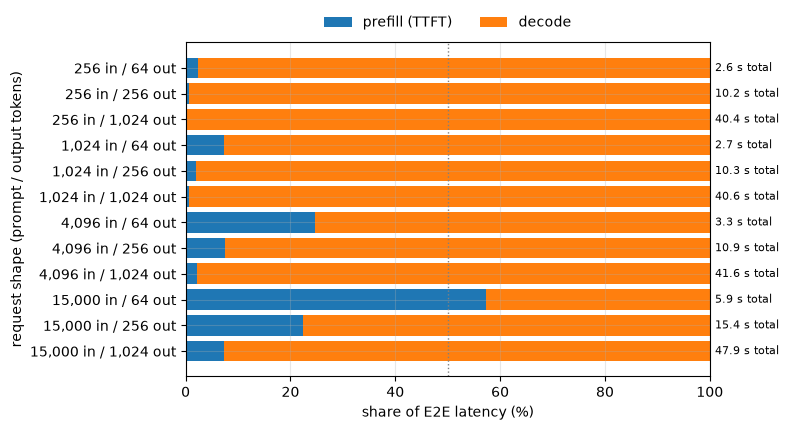

In [12]:
labels = [f"{p:,} in / {d:,} out" for p, d in zip(breakdown["prompt"], breakdown["output"])]
total = breakdown["prefill (s)"] + breakdown["decode (s)"]
prefill_pct = 100 * breakdown["prefill (s)"] / total
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.barh(labels, prefill_pct, label="prefill (TTFT)", color="C0")
ax.barh(labels, 100 - prefill_pct, left=prefill_pct, label="decode", color="C1")
for i, t in enumerate(total):
    ax.text(101, i, f"{t:.1f} s total", va="center", fontsize=8)
ax.axvline(50, color="gray", ls=":", lw=1)
ax.invert_yaxis()
ax.set(xlim=(0, 100), xlabel="share of E2E latency (%)", ylabel="request shape (prompt / output tokens)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
fig.tight_layout()

**Decode dominates** for nearly every shape. One output token takes ~39 ms,
about as long as prefilling ~190 prompt tokens (0.2 ms each), so even a 4K-token
prompt with a 64-token answer spends most of its time in decode. Only an
extreme case, a 15K-token document with a short 64-token answer such as a
summary, tips the balance toward prefill.

This is why so much LLM serving research targets decode: it is where a single
request spends its time, and it is also where the GPU's math units sit idle.

## Summary

| | Prefill | Decode (one request) |
|---|---|---|
| Tokens per forward pass | the whole prompt | 1 |
| Bottleneck | compute (FLOP/s) | memory bandwidth |
| Scales with | prompt length | number of output tokens |
| User-facing metric | TTFT | TPOT |

Decode leaves the GPU's math units almost idle. Lecture 2 shows how serving
systems put them to work by **batching** many requests together.

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [13]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "Is prefill compute-bound or memory-bound?",
     "options": ["Compute-bound", "Memory-bound"], "answer": 0,
     "explain": "Each weight is loaded once and reused for every prompt token, so arithmetic dominates."},
    {"q": "Is decode for a single request compute-bound or memory-bound?",
     "options": ["Compute-bound", "Memory-bound"], "answer": 1,
     "explain": "Each step reads all the weights to produce one token: ~0.1 ms of math versus ~16 ms of memory traffic here."},
    {"q": "A new GPU has 2× the FLOP/s of an A100 but the same memory bandwidth. Which metric improves most?",
     "options": ["TTFT", "TPOT", "Both equally", "Neither"], "answer": 0,
     "explain": "TTFT comes from compute-bound prefill, so it benefits from more FLOP/s. TPOT is limited by memory bandwidth."},
    {"q": "A new GPU has 2× the memory bandwidth of an A100 but the same FLOP/s. Which metric improves most?",
     "options": ["TTFT", "TPOT", "Both equally", "Neither"], "answer": 1,
     "explain": "Decode streams all the weights every step, so faster memory directly shortens each step."},
    {"q": "The prompt grows from 2,048 to 4,096 tokens (one request, no queueing). TTFT becomes about…",
     "options": ["the same", "2× longer", "4× longer"], "answer": 1,
     "explain": "Prefill work is ~2 × parameters × N, linear in N. The quadratic attention term is still small at this length."},
    {"q": "The prompt grows from 2,048 to 4,096 tokens. TPOT becomes about…",
     "options": ["the same", "2× longer", "4× longer"], "answer": 0,
     "explain": "Each decode step is dominated by reading 65.5 GB of weights. The extra KV cache (~0.5 GB) barely adds to it."},
    {"q": "A request has 1,000 prompt tokens and 500 output tokens. Which phase dominates its E2E latency?",
     "options": ["Prefill", "Decode"], "answer": 1,
     "explain": "TTFT ≈ 0.2 s, while decode takes ≈ 500 × 39 ms ≈ 20 s."},
    {"q": "Why does this lecture run Qwen2.5-32B on two GPUs instead of one 80 GB A100?",
     "options": ["The model needs two GPUs' worth of FLOP/s to run at all",
                 "Its 65.5 GB of weights would leave almost no memory for the KV cache",
                 "The simulator cannot model a single GPU"],
     "answer": 1,
     "explain": "Weights plus KV cache must fit in GPU memory. Splitting the weights frees memory for the KV cache, and also halves the bytes each GPU reads per step."},
])